# Coleta de dados da OCDE

Este notebook tem como objetivo explorar dados estruturais da Organização para Cooperação e Desenvolvimento Econômico (OCDE), obtidos via API SDMX 2.1, com foco nas atividades classificadas como J62 (desenvolvimento de software) e J63 (serviços de informação). A partir desses dados, são analisadas três dimensões principais do setor:

- Número de empresas (ENTR)
- Turnover total (TUTT)
- Número de empregados (EMPE)

Além disso, é derivada uma métrica de produtividade (turnover por empregado), permitindo comparações mais robustas entre países com diferentes escalas econômicas.

In [3]:
"""
Extracao de Dados OCDE - SDMX 2.1
Indicadores estruturais do setor de software (J62+J63) para Market Twin / Predicao
"""

import requests
import pandas as pd
from io import StringIO
import logging
import time

# Configuracao de logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)


# Constantes
BASE_URL = "https://sdmx.oecd.org/public/rest/data/"
DATAFLOW  = "OECD.SDD.TPS,DSD_SDBSBSC_ISIC4@DF_SDBS_ISIC4"

COLUNAS_SDMX   = ["REF_AREA", "MEASURE", "ACTIVITY", "TIME_PERIOD", "OBS_VALUE"]
COLUNAS_RENAME = ["Pais", "Indicador", "Setor", "Ano", "Valor"]

# Indicadores com cobertura util para J62+J63 (verificado empiricamente):
#   ENTR  - numero de empresas ativas           (cobertura: ~97%)
#   TUTT  - turnover total (faturamento)        (cobertura: ~95%)
#   EMPE  - numero de empregados                (cobertura: ~91%)
#
# Indicadores testados e descartados por cobertura insuficiente em J62+J63:
#   VALU  - valor adicionado                    (cobertura:  ~8%)
#   EMPT, WAGE, GROS, INVE                      (cobertura:   0%, API nao retorna dados)
MEDIDAS_PADRAO = "ENTR+TUTT+EMPE"

TIMEOUT_SEGUNDOS = 180
MAX_TENTATIVAS   = 3
PAUSA_TENTATIVA  = 10


# Funcoes auxiliares

def _construir_url(
    paises: str = "",
    medidas: str = MEDIDAS_PADRAO,
    setores: str = "J62+J63",
    inicio: int = 2010,
    fim: int = 2024,
) -> str:
    """
    Monta a URL SDMX 2.1 parametrizada.
    Deixar `paises` vazio retorna todos os paises da OCDE + parceiros.
    """
    chave  = f"A.{paises}.{medidas}.{setores}._T."
    params = f"?startPeriod={inicio}&endPeriod={fim}&dimensionAtObservation=AllDimensions"
    return f"{BASE_URL}{DATAFLOW}/{chave}{params}"


def _requisitar_com_retry(url: str, headers: dict) -> requests.Response | None:
    """
    Faz a requisicao HTTP com retry automatico em caso de falha de rede ou 5xx.
    Retorna o objeto Response em caso de sucesso, ou None apos esgotar tentativas.
    """
    for tentativa in range(1, MAX_TENTATIVAS + 1):
        try:
            log.info(f"Tentativa {tentativa}/{MAX_TENTATIVAS} -- requisitando dados...")
            response = requests.get(url, headers=headers, timeout=TIMEOUT_SEGUNDOS)

            if response.status_code == 200:
                log.info(f"Resposta recebida ({len(response.content) / 1024:.1f} KB)")
                return response

            # Erros do cliente (4xx) nao adianta tentar de novo
            if 400 <= response.status_code < 500:
                log.error(f"Erro do cliente {response.status_code}: {response.text[:500]}")
                return None

            # Erros do servidor (5xx): tenta de novo
            log.warning(f"Erro do servidor {response.status_code}. Aguardando {PAUSA_TENTATIVA}s...")
            time.sleep(PAUSA_TENTATIVA)

        except requests.exceptions.Timeout:
            log.warning(f"Timeout apos {TIMEOUT_SEGUNDOS}s. Aguardando {PAUSA_TENTATIVA}s...")
            time.sleep(PAUSA_TENTATIVA)

        except requests.exceptions.RequestException as e:
            log.error(f"Erro de rede: {e}")
            return None

    log.error("Todas as tentativas falharam.")
    return None


def _validar_e_limpar(df: pd.DataFrame) -> pd.DataFrame | None:
    """
    Valida colunas esperadas e retorna DataFrame limpo com nomes legiveis.

    NaN em OBS_VALUE sao MANTIDOS intencionalmente -- representam anos sem
    reporte para um pais/indicador especifico. O tratamento (interpolacao,
    exclusao por cobertura, etc.) sera feito em etapa posterior, conforme
    o uso: snapshot para twins ou serie temporal para predicao.
    """
    colunas_ausentes = [c for c in COLUNAS_SDMX if c not in df.columns]
    if colunas_ausentes:
        log.error(f"Colunas ausentes na resposta da API: {colunas_ausentes}")
        log.info(f"Colunas disponiveis: {df.columns.tolist()}")
        return None

    df_clean = df[COLUNAS_SDMX].copy()
    df_clean.columns = COLUNAS_RENAME

    df_clean["Ano"]   = pd.to_numeric(df_clean["Ano"],   errors="coerce")
    df_clean["Valor"] = pd.to_numeric(df_clean["Valor"], errors="coerce")

    # Diagnostico de NaN -- informativo, sem remocao
    n_nulos = df_clean["Valor"].isna().sum()
    if n_nulos > 0:
        pct = n_nulos / len(df_clean) * 100
        log.info(
            f"Valores ausentes (OBS_VALUE): {n_nulos:,} linhas ({pct:.1f}%) "
            f"-- mantidos para tratamento posterior."
        )

    return df_clean


def _pivotar(df_clean: pd.DataFrame, aggfunc: str = "last") -> pd.DataFrame:
    """
    Transforma de formato longo (long) para largo (wide), um indicador por coluna.

    aggfunc='last' prioriza a revisao mais recente em caso de duplicatas,
    comportamento mais seguro para series da OCDE que sofrem revisoes.

    NaN no wide refletem ausencia real de reporte -- nao sao artefatos do pivot.
    """
    df_pivot = df_clean.pivot_table(
        index=["Pais", "Setor", "Ano"],
        columns="Indicador",
        values="Valor",
        aggfunc=aggfunc,
    ).reset_index()

    df_pivot.columns.name = None
    return df_pivot


def diagnostico_cobertura(df: pd.DataFrame) -> None:
    """
    Imprime dois relatorios de cobertura de dados:

    1. Por indicador: % de linhas (pais+ano) com valor nao-nulo.
       Use para decidir quais indicadores tem dados suficientes
       para o modelo (recomendado: > 60%).

    2. Por pais (indicador ENTR): % de anos com valor nao-nulo.
       Use para excluir paises com serie muito incompleta.
    """
    indicadores = [c for c in df.columns if c not in ["Pais", "Setor", "Ano"]]

    cobertura_ind = (
        df[indicadores]
        .notna()
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .round(1)
        .rename("Cobertura (%)")
    )
    print("\n--- Cobertura por indicador (% de linhas pais+ano com valor) ---")
    print(cobertura_ind.to_string())

    if "ENTR" in df.columns:
        cobertura_pais = (
            df.groupby("Pais")["ENTR"]
            .apply(lambda s: s.notna().mean())
            .sort_values()
            .mul(100)
            .round(1)
        )
        print("\n--- Cobertura por pais -- ENTR (% de anos com valor) ---")
        print(cobertura_pais.to_string())


# Funcao principal

def extrair_dados_ocde(
    paises: str = "",
    medidas: str = MEDIDAS_PADRAO,
    setores: str = "J62+J63",
    inicio: int = 2010,
    fim: int = 2024,
    formato_wide: bool = True,
) -> pd.DataFrame | None:
    """
    Extrai dados estruturais do setor de software da API SDMX 2.1 da OCDE.

    Parametros
    ----------
    paises       : Codigos ISO separados por '+'. Vazio = todos os paises.
    medidas      : Indicadores SDMX separados por '+'. Ver MEDIDAS_PADRAO.
    setores      : Atividades ISIC4. J62 = software, J63 = dados/hospedagem.
    inicio / fim : Intervalo temporal (ano).
    formato_wide : Se True, pivota indicadores em colunas (ideal para ML/twins).
                   Se False, retorna formato longo (ideal para visualizacao).

    Retorna
    -------
    pd.DataFrame ou None em caso de falha.
    NaN em Valor indicam ausencia de reporte -- nao foram removidos.
    """
    url     = _construir_url(paises, medidas, setores, inicio, fim)
    headers = {"Accept": "text/csv"}

    log.info(f"URL construida:\n  {url}")

    response = _requisitar_com_retry(url, headers)
    if response is None:
        return None

    try:
        df_raw = pd.read_csv(StringIO(response.text))
    except Exception as e:
        log.error(f"Falha ao parsear CSV: {e}")
        log.debug(response.text[:1000])
        return None

    log.info(f"Linhas brutas lidas: {len(df_raw):,}")

    df_clean = _validar_e_limpar(df_raw)
    if df_clean is None:
        return None

    log.info(f"Linhas apos limpeza: {len(df_clean):,}")
    log.info(f"Paises encontrados: {df_clean['Pais'].nunique()}")
    log.info(f"Indicadores: {df_clean['Indicador'].unique().tolist()}")

    if not formato_wide:
        return df_clean

    df_final = _pivotar(df_clean)
    log.info(f"Shape final (wide): {df_final.shape}")
    return df_final


# Execucao

if __name__ == "__main__":

    log.info("=== Extracao: todos os paises, formato wide ===")
    df = extrair_dados_ocde(inicio=2010, fim=2022, formato_wide=True)

    if df is not None:
        print("\n--- Primeiras linhas ---")
        print(df.head(10).to_string(index=False))

        print(f"\n--- Shape: {df.shape} ---")
        print(f"Paises: {df['Pais'].nunique()}")
        print(f"Colunas: {df.columns.tolist()}")

        # Relatorio de cobertura -- base para decidir quais indicadores
        # e paises entram na analise de twins / predicao
        diagnostico_cobertura(df)

        df.to_csv("dados_ocde_software.csv", index=False)
        log.info("Arquivo salvo: dados_ocde_software.csv")

    # Exemplo: apenas 3 paises, formato longo (util para visualizacao)
    # df_long = extrair_dados_ocde(paises="FRA+DEU+ITA", formato_wide=False)
    # if df_long is not None:
    #     print(df_long.head(20))


--- Primeiras linhas ---
Pais Setor  Ano    EMPE   ENTR         TUTT
 ALB   J62 2019  4549.0 1167.0 15646.872070
 ALB   J62 2020  4771.0 1442.0 18850.169922
 ALB   J63 2019   912.0  445.0  2226.481201
 ALB   J63 2020  1654.0  424.0  2958.102783
 ALB   J63 2021  1798.0  291.0  4411.009277
 ALB   J63 2022  2109.0  427.0  6747.355957
 AUT   J62 2010 29315.0 8940.0  4927.700195
 AUT   J62 2011 32070.0 9363.0  5808.399902
 AUT   J62 2012 34409.0 9650.0  6372.299805
 AUT   J62 2013 36421.0 9964.0  7091.100098

--- Shape: (1020, 6) ---
Paises: 43
Colunas: ['Pais', 'Setor', 'Ano', 'EMPE', 'ENTR', 'TUTT']

--- Cobertura por indicador (% de linhas pais+ano com valor) ---
ENTR    97.1
TUTT    94.8
EMPE    91.0

--- Cobertura por pais -- ENTR (% de anos com valor) ---
Pais
COL      0.0
KOR      0.0
MKD     91.7
ALB    100.0
BGR    100.0
BIH    100.0
BEL    100.0
AUT    100.0
CRI    100.0
CYP    100.0
CZE    100.0
DEU    100.0
DNK    100.0
ESP    100.0
BRA    100.0
CHE    100.0
FIN    100.0
EST   

# Script para extração de dados da OCDE

## 1. Constantes definidas no início

```py
BASE_URL = "https://sdmx.oecd.org/public/rest/data/"
DATAFLOW  = "OECD.SDD.TPS,DSD_SDBSBSC_ISIC4@DF_SDBS_ISIC4"

MEDIDAS_PADRAO = "ENTR+TUTT+EMPE"
```

Separa o endereço fixo da API do identificador do dataset. O `DATAFLOW` é o nome que a OCDE dá para essa tabela de dados específica — estatísticas de negócios por setor **ISIC4**.

**ISIC4** é a *International Standard Industrial Classification*, revisão 4 — a classificação internacional padrão de atividades econômicas da ONU. É basicamente um sistema de códigos que organiza toda a economia em setores hierárquicos. A estrutura funciona assim:

```
Seção   J        — Informação e comunicação
  Divisão  62    — Atividades de tecnologia da informação
    Grupo    620  — Atividades de TI
      Classe 6201 — Desenvolvimento de software sob encomenda
      Classe 6202 — Consultoria em TI
      Classe 6209 — Outras atividades de TI
  Divisão  63    — Atividades de serviços de informação
    Grupo    631  — Portais, hospedagem, processamento de dados
```

A OCDE coleta dados estruturais — número de empresas, faturamento, empregados — de cada país membro, e organiza esses dados usando o ISIC4 como taxonomia comum. Isso permite comparar "o setor de software da França" com "o setor de software da Alemanha" usando a mesma definição de o que é "setor de software".

`MEDIDAS_PADRAO` centraliza os 3 indicadores com cobertura útil em uma única constante no topo do arquivo, evitando que o valor precise ser repetido ou editado em múltiplos lugares.

## 2. `_construir_url`

Monta a query dinamicamente. A parte mais importante é a `chave`:

```py
chave = f"A.{paises}.{medidas}.{setores}._T."
# Exemplo: "A..ENTR+TUTT+EMPE.J62+J63._T."
```

Cada posição separada por `.` é uma dimensão do SDMX — frequência, país, medida, setor, etc. O `paises` vazio entre os dois pontos significa "todos os países". É a sintaxe da própria API.

## 3. `_requisitar_com_retry`

Faz a chamada HTTP com três camadas de proteção:

- **Timeout:** Não trava o script se a OCDE demorar demais.
- **Distinção 4xx vs 5xx:** Erro 4xx (URL errada, parâmetro inválido) não adianta tentar de novo. Erros 5xx (servidor instável) valem retry.
- **Exceções de rede:** `Timeout` e `RequestException` são capturados separadamente porque têm causas diferentes.

## 4. `_validar_e_limpar`

Faz três coisas:

1. Confirma que as colunas esperadas da API realmente vieram — a OCDE já mudou o schema antes.
2. Renomeia os códigos SDMX (`REF_AREA`, `OBS_VALUE`) para nomes legíveis.
3. Converte tipos — sem isso, `Ano` e `Valor` chegam como `object` (string), o que quebra qualquer operação numérica depois.

O **NaN** é apenas logado, não removido. O log informa quantos existem e qual o percentual — informação necessária na etapa de tratamento posterior.

## 5. `_pivotar`

Transforma o formato longo em largo:

```py
# Antes (long)                      # Depois (wide)
Pais  Indicador  Ano   Valor         Pais  Ano   ENTR   TUTT   EMPE
FRA   ENTR       2015  1200    →    FRA   2015  1200   45000  85000
FRA   TUTT       2015  45000        FRA   2016  1250   47000  87000
FRA   EMPE       2015  85000
```

O `index=["Pais", "Setor", "Ano"]` preserva a dimensão temporal — essencial para comparar trajetórias no sistema de twins. O `aggfunc='last'` resolve duplicatas pegando o valor mais recente, que em séries da OCDE costuma ser a revisão mais atualizada.

## 6. `diagnostico_cobertura`

Função separada (não mais inline no `__main__`) que gera dois relatórios:

**Por indicador** — % de linhas (país+ano) com valor não-nulo. Use para decidir quais indicadores têm dados suficientes para entrar no modelo (recomendado: > 60%).

**Por país** — % de anos com valor não-nulo para `ENTR`. Use para excluir países com série muito incompleta antes da análise de twins.

```py
# Pode ser chamada a qualquer momento, nao so na execucao direta
diagnostico_cobertura(df)
```

## 7. `extrair_dados_ocde`

É o orquestrador — chama as funções anteriores em sequência e expõe os parâmetros principais:

- `paises` — filtrar ou pegar todos.
- `medidas` — quais indicadores extrair (padrão: os 3 de `MEDIDAS_PADRAO`).
- `formato_wide` — `True` para ML/twins, `False` para visualização.

## 8. Retorno e parâmetros padrão

**Países:** todos — o `paises=""` vazio na URL vira `A..ENTR+...` — os dois pontos consecutivos significam "sem filtro", retornando todos os membros da OCDE + países parceiros que reportaram dados.

**Setores:**
- `J62` — desenvolvimento de software
- `J63` — hospedagem de dados, portais web, processamento de dados

**Indicadores em uso (cobertura verificada empiricamente):**

| Código | O que mede | Cobertura |
|--------|-----------|-----------|
| `ENTR` | Número de empresas ativas | ~97% |
| `TUTT` | Turnover total (faturamento) | ~95% |
| `EMPE` | Número de empregados | ~91% |

**Indicadores testados e descartados:**

> `VALU` (~8%) e `EMPT`, `WAGE`, `GROS`, `INVE` (0% — API não retorna dados para J62+J63) foram testados e excluídos por cobertura insuficiente.

**Período:** 2010 a 2024 — mas na prática os anos mais recentes costumam ter cobertura parcial ou nenhuma, porque os países têm defasagem de 1 a 3 anos para reportar. Por isso no `__main__` o exemplo usa `fim=2022`.

Os códigos de país seguem o padrão ISO 3166-1 alpha-3 da OCDE — `BRA` para Brasil, `USA` para EUA, `JPN` para Japão, etc.

# Gráficos

Paises selecionados (15): ['AUT', 'BEL', 'BGR', 'CZE', 'CYP', 'CRI', 'TUR', 'SWE', 'SVK', 'DEU', 'DNK', 'ESP', 'EST', 'FRA', 'ITA']
Salvo: 1_serie_temporal_entr.png


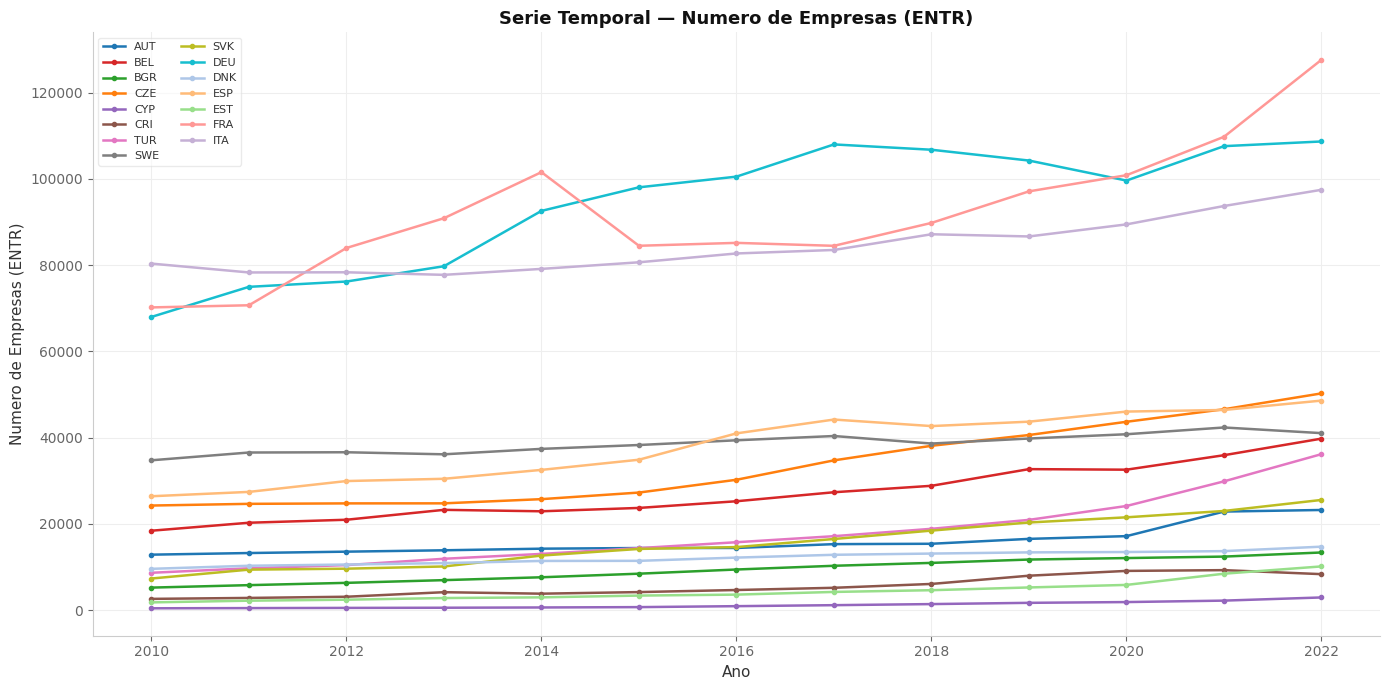

Salvo: 2_produtividade_tutt_empe.png


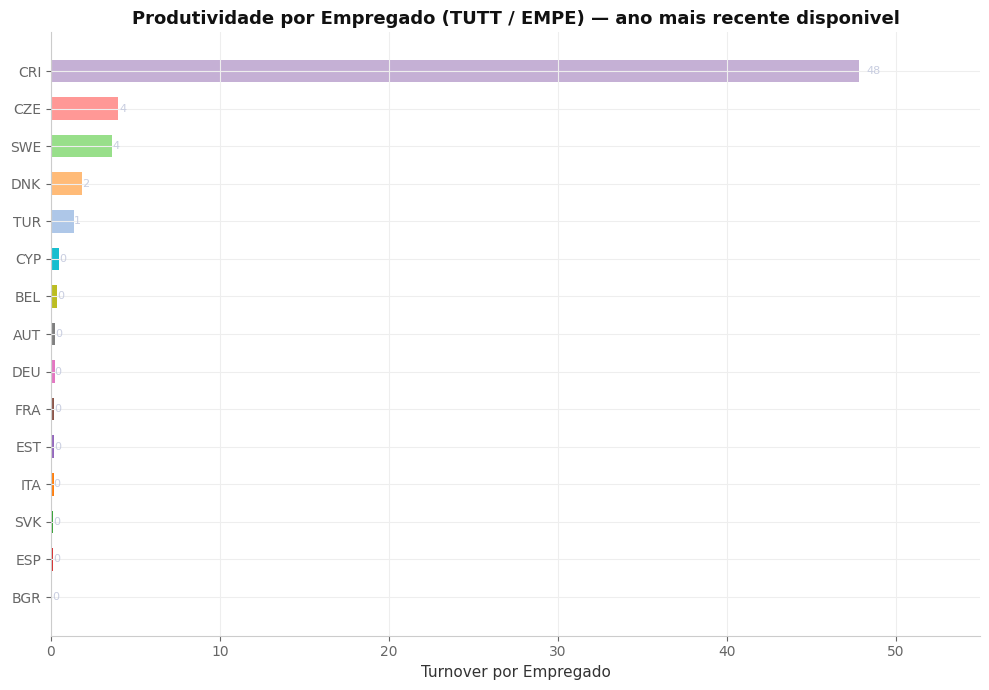

Salvo: 3_scatter_entr_tutt.png


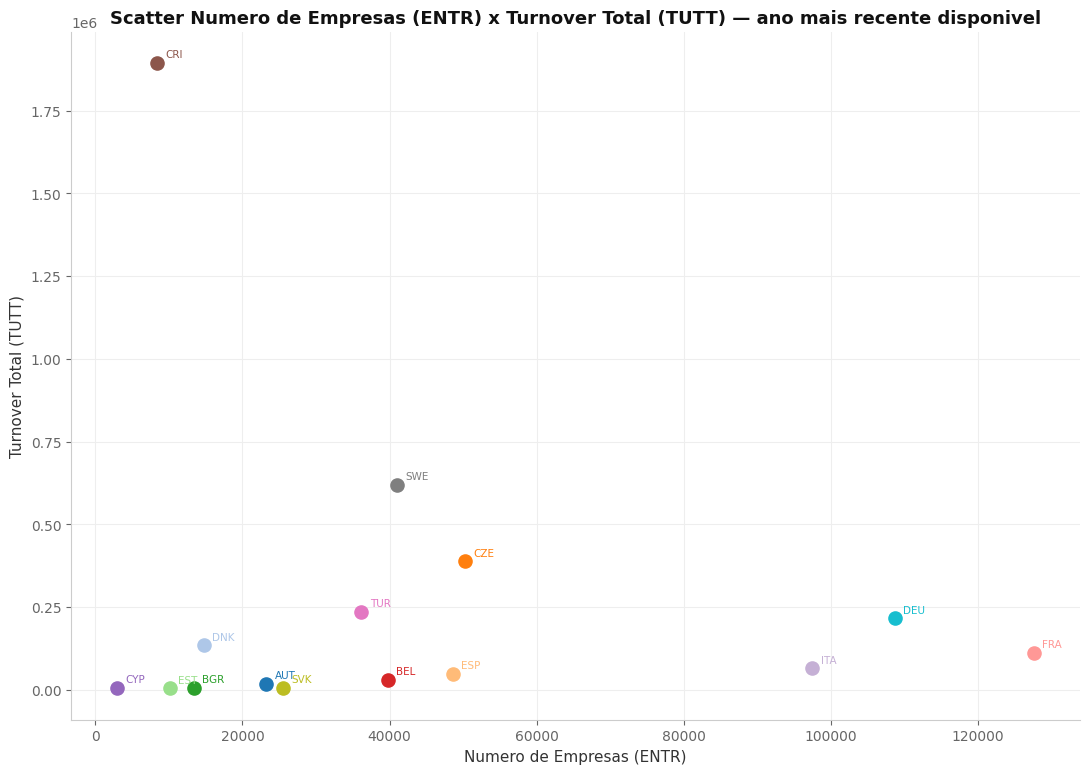

Salvo: 4_scatter_entr_empe.png


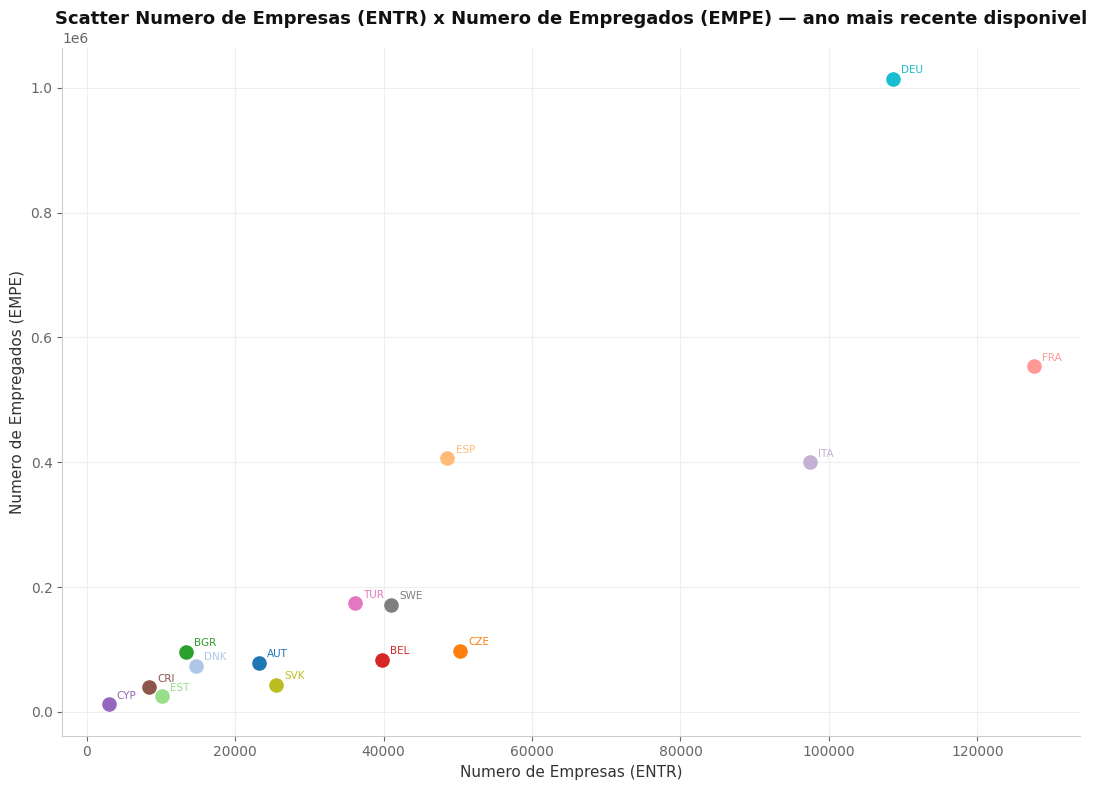

In [5]:
"""
Visualizacoes - Dados OCDE Software (J62+J63)
Requer: dados_ocde_software.csv gerado pelo extrair_dados_ocde.py
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Configuracao global de estilo ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     "#cccccc",
    "axes.labelcolor":    "#333333",
    "axes.titlecolor":    "#111111",
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#eeeeee",
    "grid.linewidth":     0.8,
    "xtick.color":        "#666666",
    "ytick.color":        "#666666",
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "text.color":         "#333333",
    "legend.facecolor":   "white",
    "legend.edgecolor":   "#dddddd",
    "legend.fontsize":    8,
    "figure.titlesize":   15,
    "figure.titleweight": "bold",
})

# Paleta de paises — cores distintas e legíveis em fundo claro
PALETA = [
    "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5",
]


# ── Carregamento e pre-processamento ───────────────────────────────────────────

def carregar_dados(caminho: str = "dados_ocde_software.csv") -> pd.DataFrame:
    df = pd.read_csv(caminho)
    df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

    # Agrega J62+J63 somando por pais+ano (alguns paises reportam separado)
    df = (
        df.groupby(["Pais", "Ano"], as_index=False)[["ENTR", "TUTT", "EMPE"]]
        .sum(min_count=1)  # min_count=1: so soma se tiver pelo menos 1 valor valido
    )

    # Produtividade: turnover por empregado
    df["PROD"] = df["TUTT"] / df["EMPE"]

    return df


def selecionar_paises(df: pd.DataFrame, n: int = 15) -> list[str]:
    """
    Seleciona os N paises com mais anos de dados completos (ENTR + TUTT + EMPE).
    Garante que os graficos nao fiquem poluidos com paises de serie incompleta.
    """
    completos = df.dropna(subset=["ENTR", "TUTT", "EMPE"])
    contagem  = completos.groupby("Pais")["Ano"].count().sort_values(ascending=False)
    return contagem.head(n).index.tolist()


# ── Graficos ───────────────────────────────────────────────────────────────────

def grafico_serie_temporal(
    df: pd.DataFrame,
    paises: list[str],
    indicador: str = "ENTR",
    titulo_indicador: str = "Numero de Empresas (ENTR)",
    salvar: str | None = "serie_temporal.png",
) -> None:
    """
    Grafico 1 — Serie temporal por pais.
    Mostra a evolucao de um indicador ao longo do tempo para um conjunto de paises.
    """
    fig, ax = plt.subplots(figsize=(14, 7))

    for i, pais in enumerate(paises):
        dados = df[df["Pais"] == pais].sort_values("Ano")
        cor   = PALETA[i % len(PALETA)]
        ax.plot(
            dados["Ano"], dados[indicador],
            label=pais, color=cor, linewidth=1.8, marker="o", markersize=3,
        )

    ax.set_title(f"Serie Temporal — {titulo_indicador}")
    ax.set_xlabel("Ano")
    ax.set_ylabel(titulo_indicador)
    ax.legend(loc="upper left", ncol=2, framealpha=0.6)
    fig.tight_layout()

    if salvar:
        fig.savefig(salvar, dpi=150, bbox_inches="tight")
        print(f"Salvo: {salvar}")
    plt.show()


def grafico_produtividade(
    df: pd.DataFrame,
    paises: list[str],
    ano: int | None = None,
    salvar: str | None = "produtividade.png",
) -> None:
    """
    Grafico 2 — Turnover por empregado (TUTT/EMPE) em barras horizontais.
    Normaliza pelo tamanho do mercado, permitindo comparar paises de escalas diferentes.
    Se `ano` for None, usa o ano mais recente disponivel para cada pais.
    """
    registros = []
    for pais in paises:
        dados = df[(df["Pais"] == pais) & df["PROD"].notna()].sort_values("Ano")
        if dados.empty:
            continue
        linha = dados[dados["Ano"] == ano] if ano else dados.iloc[[-1]]
        if not linha.empty:
            registros.append({"Pais": pais, "PROD": linha["PROD"].values[0], "Ano": linha["Ano"].values[0]})

    if not registros:
        print("Nenhum dado disponivel para o grafico de produtividade.")
        return

    df_prod = pd.DataFrame(registros).sort_values("PROD", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    cores = [PALETA[i % len(PALETA)] for i in range(len(df_prod))]
    bars  = ax.barh(df_prod["Pais"], df_prod["PROD"], color=cores, height=0.6)

    # Rotulo de valor no final de cada barra
    for bar, val in zip(bars, df_prod["PROD"]):
        ax.text(
            bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", ha="left", fontsize=8, color="#c8cde0",
        )

    ano_label = ano if ano else "ano mais recente disponivel"
    ax.set_title(f"Produtividade por Empregado (TUTT / EMPE) — {ano_label}")
    ax.set_xlabel("Turnover por Empregado")
    ax.margins(x=0.15)
    fig.tight_layout()

    if salvar:
        fig.savefig(salvar, dpi=150, bbox_inches="tight")
        print(f"Salvo: {salvar}")
    plt.show()


def grafico_scatter(
    df: pd.DataFrame,
    paises: list[str],
    eixo_x: str,
    eixo_y: str,
    label_x: str,
    label_y: str,
    ano: int | None = None,
    salvar: str | None = "scatter.png",
) -> None:
    """
    Grafico 3/4 — Scatter entre dois indicadores.
    Cada ponto e um pais. Permite identificar clusters e candidatos a twins.
    Se `ano` for None, usa o ano mais recente disponivel para cada pais.
    """
    fig, ax = plt.subplots(figsize=(11, 8))

    for i, pais in enumerate(paises):
        dados = df[(df["Pais"] == pais) & df[eixo_x].notna() & df[eixo_y].notna()].sort_values("Ano")
        if dados.empty:
            continue
        linha = dados[dados["Ano"] == ano] if ano else dados.iloc[[-1]]
        if linha.empty:
            continue

        x = linha[eixo_x].values[0]
        y = linha[eixo_y].values[0]
        cor = PALETA[i % len(PALETA)]

        ax.scatter(x, y, color=cor, s=90, zorder=3)
        ax.annotate(
            pais, (x, y),
            textcoords="offset points", xytext=(6, 4),
            fontsize=7.5, color=cor,
        )

    ano_label = ano if ano else "ano mais recente disponivel"
    ax.set_title(f"Scatter {label_x} x {label_y} — {ano_label}")
    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)
    fig.tight_layout()

    if salvar:
        fig.savefig(salvar, dpi=150, bbox_inches="tight")
        print(f"Salvo: {salvar}")
    plt.show()


# ── Execucao ───────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    df = carregar_dados("dados_ocde_software.csv")
    paises = selecionar_paises(df, n=15)
    print(f"Paises selecionados ({len(paises)}): {paises}")

    # ── Grafico 1: Serie temporal — numero de empresas
    grafico_serie_temporal(
        df, paises,
        indicador="ENTR",
        titulo_indicador="Numero de Empresas (ENTR)",
        salvar="1_serie_temporal_entr.png",
    )

    # ── Grafico 2: Produtividade por empregado (ano mais recente)
    grafico_produtividade(
        df, paises,
        ano=None,           # None = ano mais recente disponivel por pais
        salvar="2_produtividade_tutt_empe.png",
    )

    # ── Grafico 3: Scatter ENTR x TUTT
    grafico_scatter(
        df, paises,
        eixo_x="ENTR", eixo_y="TUTT",
        label_x="Numero de Empresas (ENTR)",
        label_y="Turnover Total (TUTT)",
        ano=None,
        salvar="3_scatter_entr_tutt.png",
    )

    # ── Grafico 4: Scatter ENTR x EMPE
    grafico_scatter(
        df, paises,
        eixo_x="ENTR", eixo_y="EMPE",
        label_x="Numero de Empresas (ENTR)",
        label_y="Numero de Empregados (EMPE)",
        ano=None,
        salvar="4_scatter_entr_empe.png",
    )

### **Observações:**

* `selecionar_paises` — em vez de listar países manualmente, seleciona automaticamente os 15 com mais anos de dados completos nos 3 indicadores. Evita que países com série incompleta poluam os gráficos. Podemos mudar o `n=15` conforme a necessidade.

* **Agregação J62+J63** — o `carregar_dados` soma os dois setores por país+ano com `min_count=1`, então cada ponto nos gráficos representa o setor de software+dados combinado. Sem isso, cada país apareceria duplicado nos scatters.

* `ano=None` nos gráficos 2, 3 e 4 — usa o ano mais recente disponível para cada país individualmente, o que é mais justo do que fixar um ano e perder países que não reportaram naquele específico. Você pode passar ano=2021 por exemplo para fixar um ponto de comparação.

# Análise dos Gráficos

# Análise Exploratória do Setor de Software (OCDE — J62+J63)

## 1. Visão Geral

A análise exploratória foi conduzida com base em dados estruturais da OCDE para o setor de software (atividades J62 e J63), considerando três dimensões principais:

- Número de empresas (ENTR)
- Turnover total (TUTT)
- Número de empregados (EMPE)

A partir dessas variáveis, foi derivada uma métrica adicional:

- Produtividade (PROD = TUTT / EMPE)

Os gráficos gerados permitem avaliar a evolução temporal, diferenças estruturais entre países e relações entre escala, intensidade de trabalho e eficiência econômica.

---

## 2. Série Temporal — Número de Empresas (ENTR)

A análise da série temporal indica um crescimento consistente no número de empresas de software na maioria dos países analisados ao longo do período.

Observações relevantes:

- Países como França (FRA) e Alemanha (DEU) apresentam maior escala absoluta, refletindo mercados mais maduros.
- Economias como República Tcheca (CZE), Turquia (TUR) e Estônia (EST) demonstram crescimento mais acelerado, sugerindo expansão recente do setor.
- Alguns países exibem padrões de estabilização após períodos de crescimento, indicando possível maturidade ou saturação parcial do mercado.

**Interpretação:**
O crescimento generalizado sugere uma tendência estrutural de expansão do setor de software na OCDE, com diferenças claras entre mercados consolidados e emergentes.

---

## 3. Produtividade — Turnover por Empregado (TUTT / EMPE)

O gráfico de produtividade revela forte heterogeneidade entre países.

Principais achados:

- A Costa Rica (CRI) apresenta produtividade significativamente superior aos demais países, configurando um outlier.
- Países como Suécia (SWE) e República Tcheca (CZE) também demonstram níveis elevados de eficiência.
- Economias de maior escala (FRA, DEU, ITA) apresentam produtividade relativamente mais baixa.

**Interpretação:**
A produtividade parece estar mais associada ao grau de especialização e estrutura do setor do que ao tamanho absoluto do mercado. Países menores podem concentrar atividades de maior valor agregado, enquanto economias maiores tendem a apresentar maior heterogeneidade.

---

## 4. Relação entre Número de Empresas e Turnover (ENTR × TUTT)

O gráfico de dispersão evidencia uma correlação positiva entre número de empresas e faturamento total, conforme esperado.

No entanto, destacam-se padrões importantes:

- Presença de outliers, especialmente CRI, com alto turnover e baixo número de empresas.
- Formação de clusters distintos:
  - Países de alta escala (ex: FRA, DEU, ITA)
  - Países de alta eficiência (ex: SWE, CZE)
  - Países de baixa escala (ex: BGR, EST, CYP)

**Interpretação:**
A relação entre escala e faturamento não é linear homogênea, indicando diferenças estruturais na composição do setor entre países.

---

## 5. Relação entre Número de Empresas e Empregados (ENTR × EMPE)

Este gráfico permite avaliar a intensidade de trabalho e o tamanho médio das empresas.

Principais observações:

- Alemanha (DEU) apresenta alta quantidade de empregados proporcional ao número de empresas, sugerindo empresas maiores.
- França (FRA) possui muitas empresas com menor proporção de empregados, indicando maior presença de pequenas e médias empresas.
- Espanha (ESP) demonstra maior intensidade de trabalho relativa.
- Países menores apresentam baixa escala em ambas as dimensões.

**Interpretação:**
A estrutura do mercado varia significativamente entre países, com diferenças no porte médio das empresas e na intensidade de uso de mão de obra.

---

## 6. Síntese Estrutural

A análise conjunta dos gráficos sugere que o setor de software pode ser caracterizado por três dimensões principais:

- **Escala**: número de empresas
- **Intensidade de trabalho**: número de empregados
- **Eficiência econômica**: turnover por empregado

Essas dimensões dão origem a diferentes perfis de mercado:

1. **Mercados maduros**  
   Alta escala, maior heterogeneidade e menor produtividade média.

2. **Mercados especializados**  
   Menor escala, porém alta produtividade e eficiência.

3. **Mercados emergentes**  
   Crescimento acelerado, com estrutura ainda em consolidação.

---

## 7. Considerações Metodológicas

- Valores ausentes (NaN) foram preservados para manter a integridade das séries temporais.
- A análise considera o ano mais recente disponível por país nos gráficos de comparação.
- A presença de outliers pode influenciar interpretações e sugere a necessidade de análises complementares (ex: transformação logarítmica ou filtragem).

---

## 8. Implicações

Os resultados indicam que comparações internacionais no setor de software devem considerar não apenas o tamanho do mercado, mas também sua estrutura e especialização.

A identificação de padrões e clusters abre caminho para aplicações como:

- construção de *market twins*
- modelagem preditiva
- análise comparativa de políticas industriais

---